In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from shapely import wkt
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from conf import config


/home/lgraff/ENTER/envs/py39/lib/python3.9/site-packages/geopandas/tools/clip.py:67: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


<AxesSubplot: >

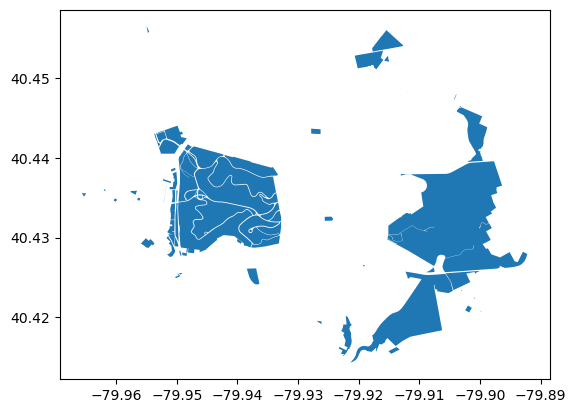

In [2]:
neighborhoods_gdf = gpd.read_file(config['paths']['data']['neighborhoods_in'])
hoods_keep_gdf = neighborhoods_gdf[neighborhoods_gdf['hood'].isin(config['geography']['neighborhoods'])]
hoods_dissolved = hoods_keep_gdf.dissolve()
parks_path = Path().resolve() / 'parks' / 'PGHWebParks.shp'
parks_gdf = gpd.read_file(parks_path, mask=hoods_dissolved).to_crs(hoods_keep_gdf.crs)
parks_gdf = gpd.clip(parks_gdf, hoods_dissolved)
parks_gdf.plot()

<AxesSubplot: title={'center': 'Study Area'}, xlabel='Longitude', ylabel='Latitude'>

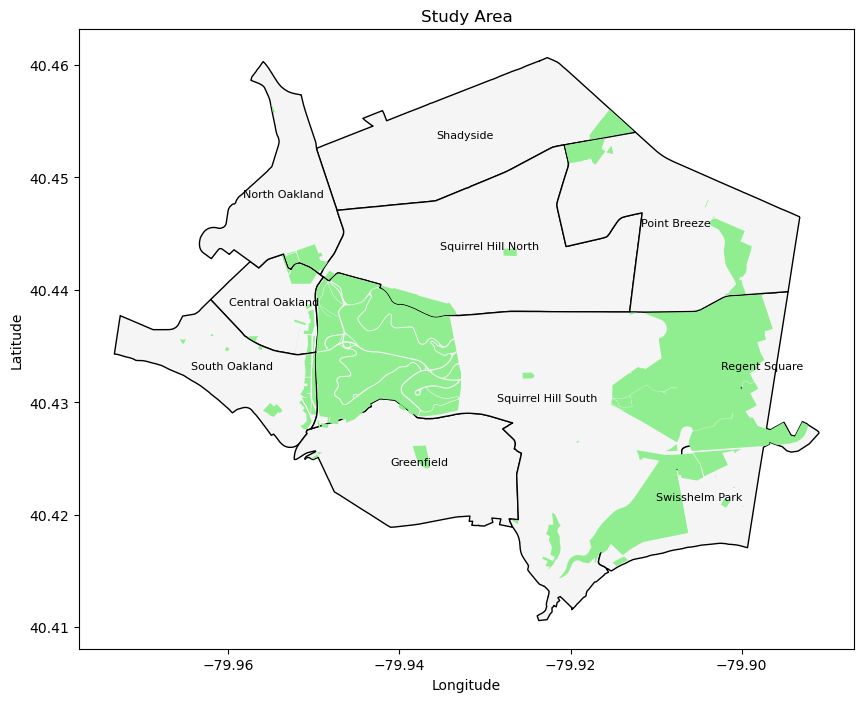

In [3]:
# Plot neighborhood outlines and annotate with names
fig, ax = plt.subplots(figsize=(10, 10))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Study Area')
hoods_keep_gdf.plot(ax=ax, color='whitesmoke', edgecolor='black')
# Add neighborhood names to the plot
for idx, row in hoods_keep_gdf.iterrows():
    plt.annotate(text=row['hood'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                horizontalalignment='center', fontsize=8, color='black')
parks_gdf.plot(ax=ax, color='lightgreen')
# Plot bikeshare candidates

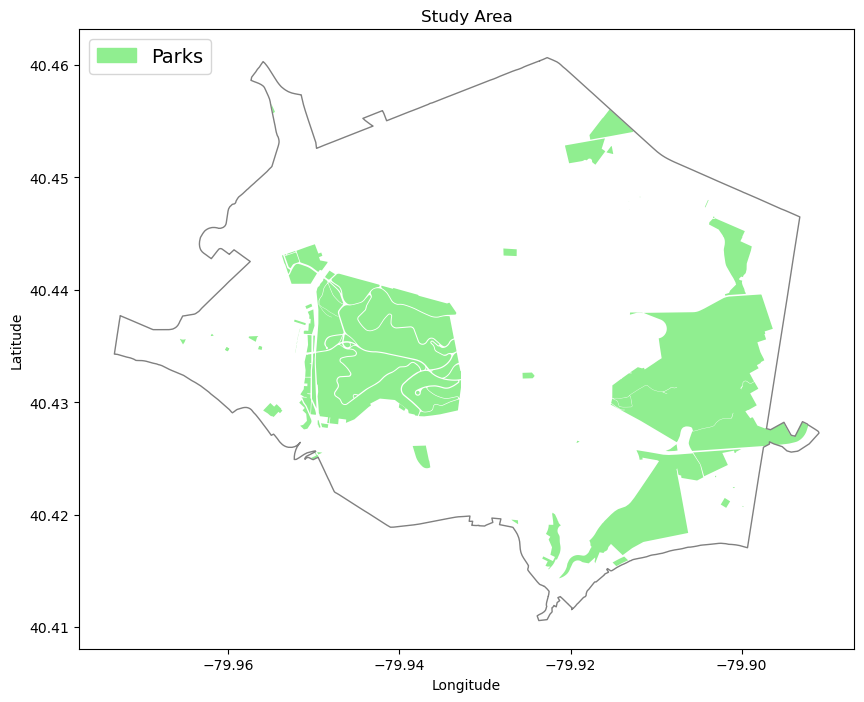

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot microtransit service zone candidates   
parks_gdf.plot(ax=ax, color='lightgreen') 
# Plot neighborhood outlines and annotate with names
hoods_dissolved.plot(ax=ax, facecolor='none', edgecolor='gray')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Study Area')
# Create custom legend handles
custom_handles = [
    Patch(facecolor='lightgreen', edgecolor='lightgreen', label='Parks'),
]

# Add the custom legend
ax.legend(handles=custom_handles, loc='upper left', fontsize=14)

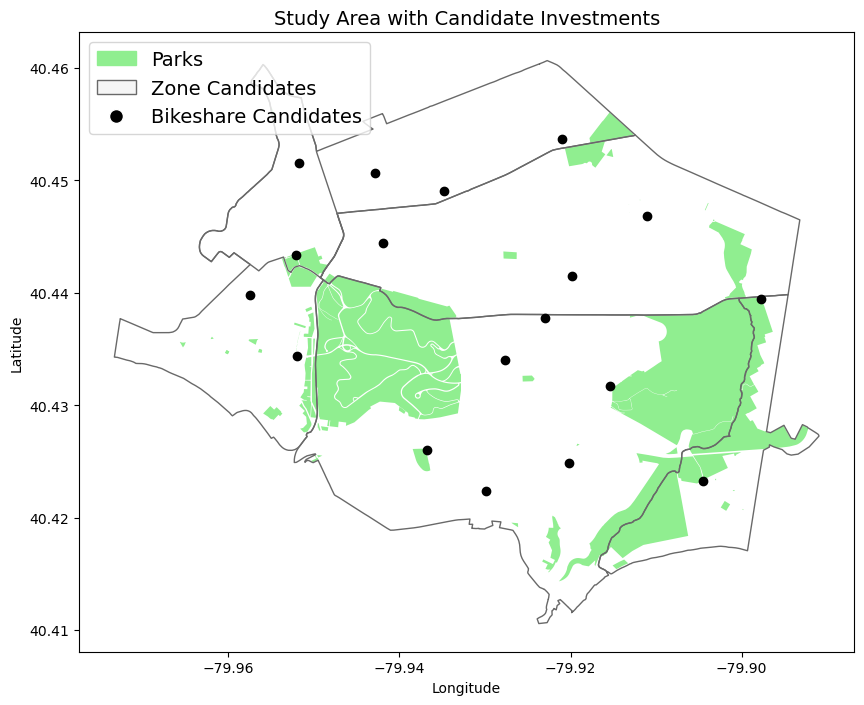

In [14]:
bikeshare_path = config['optimization']['candidates']['bikeshare_csv']
bikeshare_mymaps_csv = pd.read_csv(bikeshare_path)
bikeshare_gdf = gpd.GeoDataFrame(bikeshare_mymaps_csv, geometry=bikeshare_mymaps_csv['WKT'].apply(wkt.loads), crs='EPSG:4326').reset_index()[['index','geometry']]

fig, ax = plt.subplots(figsize=(10, 10))

# Plot microtransit service zone candidates   
parks_gdf.plot(ax=ax, color='lightgreen') 
zone_path = config['paths']['data']['microtransit_zones']   
zone_gdf = gpd.read_file(zone_path)
zone_gdf.plot(ax=ax, facecolor='none', edgecolor='dimgrey', label='Zone Candidates')
# Plot neighborhood outlines and annotate with names
# hoods_keep_gdf.plot(ax=ax, color='lightblue', edgecolor='black')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Study Area with Candidate Investments', fontsize=14)

# Add neighborhood names to the plot
# for idx, row in hoods_keep_gdf.iterrows():
#     plt.annotate(text=row['hood'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
#                 horizontalalignment='center', fontsize=8, color='black')
# Plot bikeshare candidates
bikeshare_gdf.plot(ax=ax, color='black', label='Bikeshare Candidates')
# Create custom legend handles
custom_handles = [
    Patch(facecolor='lightgreen', edgecolor='lightgreen', label='Parks'),
    Patch(facecolor='whitesmoke', edgecolor='dimgrey', label='Zone Candidates'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Bikeshare Candidates')
]

# Add the custom legend
ax.legend(handles=custom_handles, loc='upper left', fontsize=14)

plt.show()

In [9]:
bikeshare_df

,WKT,name,description
0,POINT (-79.9419717 40.4444567),Point 2,NaN
1,POINT (-79.9347834 40.4490942),Point 3,NaN
2,POINT (-79.9209646 40.4536499),Point 4,NaN
3,POINT (-79.8969662 40.4394658),Point 5,NaN
4,POINT (-79.9014723 40.4204535),Point 7,NaN
5,POINT (-79.9153381 40.4317123),Point 9,NaN
6,POINT (-79.9276977 40.4339989),Point 10,NaN
7,POINT (-79.9110125 40.4468493),Point 11,NaN
8,POINT (-79.9198691 40.4414869),Point 12,NaN
9,POINT (-79.9290745 40.4527949),Point 13,NaN
